![](https://i.ibb.co/M9wXszV/cardio-sonix-pipeline-1.jpg)

# Libraries

In [1]:
# Model development
from typing import Optional, Literal
import torch 
import torch.nn as nn

# Model testing
import pytorch_lightning as pl
import pandas as pd
from cardiosonix import ClassifyDatasetParams, ETLPipelineParams
from cardiosonix.pipeline import CardioAnomalyDataset
from torch.utils.data import DataLoader

ModuleNotFoundError: No module named 'cardiosonix'

## SEED

In [ ]:
pl.seed_everything(568538200)
torch.cuda.is_available()

# Constants

In [ ]:
dataset_params = ClassifyDatasetParams(
    extra_filepath="../data/DHD/extra/CDC_survey_2020.csv",
    audio_dirpath="../data/DHD/audio",
    labels_filepath="../data/DHD/labels.csv",
    split_ratio=[0.80, 0.20],
    merge_classes={
        "artifact": ["artifact"],
        "healthy": ["normal"],
        "abnormal": ["murmur", "extrahls", "extrastole"]
    }
)

etl_pipeline_params = ETLPipelineParams(
    scaler="Normalizer",
    encoder="OneHotEncoder",
    sample_rate=16000,
    duration=20,
    mono=True,
    extractor="MFCC",
    extractor_kwargs={
        "n_fft": 2048,
        "win_length": 2048,
        "hop_length": 1024,
        "n_mels": 82,
        "n_mfcc": 82,
        "average_by": None
    }
)

# Build val dataset for model inference

In [4]:
dataset = CardioAnomalyDataset(dataset_params, etl_pipeline_params, stage="val")
loader = DataLoader(dataset, batch_size=2)
mfcc, tabular, label = dataset[0]
print(f"{mfcc.shape=}, {label.shape}, {tabular.shape}")

Global seed set to 568538200


mfcc.shape=torch.Size([313, 82]), torch.Size([]), torch.Size([1, 50])


# Building multimodal model

## LSTM

![](https://habrastorage.org/r/w1560/web/67b/04f/73b/67b04f73b4c34ba38edfa207e09de07c.png)

# Residual block

In [18]:
class ResidualUnite(nn.Module):
    """
    This class implements residual block with shortcut connections.
    
    Note.
    This is pre-activation residual unite architecture.
    It means that architecture seems like below:
    
    >>> unite = nn.Sequential(
    >>>     BatchNorm1d()
    >>>     ReLU()
    >>>     Conv1d()
    >>>     BatchNorm1d()
    >>>     ReLU()
    >>>     Conv1d()
    >>> )   
        
    :param in_channels (int): number of input channels
    :param out_channels (int): number of output channels 
    :param downsample (boolean): if true, then first convolution downsample 
    :param activation (str): activation function which was used to apply before convolution (default: relu)
    """
    
    activations = nn.ModuleDict(
        {
            "relu": nn.ReLU(),
            "leaky_relu": nn.LeakyReLU(),
            "relu6": nn.ReLU6()
        }
    )
        
    def __init__(self, 
                 kernels: int,
                 downsample: bool,
                 activation: Literal["relu", "leaky_relu", "relu6"] = "relu"
                 ):
        super().__init__()
            
        self.shortcut = nn.Sequential()
        self.activation = self.activations[activation]
        
        self.bn1 = nn.LazyBatchNorm1d()
        self.conv1 = nn.LazyConv1d(
            out_channels=kernels, 
            kernel_size=3, 
            stride=(2 if downsample else 1),
            padding=1
        )
        
        self.bn2 = nn.LazyBatchNorm1d()
        self.conv2 = nn.Conv1d(
            in_channels=kernels, 
            out_channels=kernels, 
            kernel_size=3, 
            stride=1,
            padding=1
        )

        if downsample:
            self.shortcut = nn.Sequential(
                nn.LazyConv1d(out_channels=kernels, kernel_size=1, stride=2),
                nn.LazyBatchNorm1d()
            )
        
    def forward(self, x: torch.FloatTensor) -> torch.FloatTensor:
        shortcut = self.shortcut(x)
        x = self.conv1(self.activation(self.bn1(x)))  
        x = self.conv2(self.activation(self.bn2(x)))
        return x + shortcut

# ResNet

In [19]:
class ResNet(nn.Module):
    """
    ResNet
    """
    
    __backbones: dict = {
        "resnet18": {
            64: 2, 
            128: 2, 
            256: 2, 
            512: 2
        },
        "resnet34": {
            64: 3,
            128: 4, 
            256: 6,
            512: 3
        }
    }
    
    def __init__(self, 
                 input_shape: tuple[int, int], 
                 stem_channels: Optional[int] = 64,
                 backbone: Optional[dict] = None
                 ):
        super().__init__()
        self.input_shape = input_shape
        self.backbone = backbone if backbone else self.__backbones["resnet18"]
        self.residual_groups = self.__build_groups()
        
        self.stem = nn.Sequential(
            nn.Conv1d( 
                in_channels=input_shape[0],
                out_channels=stem_channels, 
                kernel_size=5, 
                stride=2
            ),
            nn.MaxPool1d(kernel_size=3, stride=2)
        )
        
    @property
    def output_shape(self) -> int:
        return list(self.backbone.keys())[-1]
    
    @staticmethod
    def __build_group(unites: int, kernels: int, downsample: bool) -> nn.Sequential:
        group = nn.ModuleList()
        for index in range(unites):
            if index == 0 and downsample:
                unite = ResidualUnite(kernels, downsample)
            else:
                unite = ResidualUnite(kernels, False)
            group.append(unite)
        return nn.Sequential(*group)
    
    def __build_groups(self) -> nn.Sequential:
        groups = nn.ModuleList()
        for index, (kernels, units) in enumerate(self.backbone.items()):
            if index == 0:
                group = self.__build_group(units, kernels, False)
            else:
                group = self.__build_group(units, kernels, True)
            groups.append(group)
        return nn.Sequential(*groups)
    
    def forward(self, x: torch.FloatTensor) -> torch.FloatTensor:
        x = self.stem(x)
        return self.residual_groups(x).mean(1)

# DenseMixer

In [50]:
class Concat(nn.Module):
    def __init__(self, dim: Optional[int] = 0):
        super().__init__()
        self.dim = dim
    
    def check_sanity(self, x: list | tuple) -> list:
        return [
            data.squeeze(self.dim) 
            for data in x 
            if isinstance(data, torch.FloatTensor)
        ]
    
    def forward(self, 
                x: list[torch.FloatTensor | None, ...] | tuple[torch.FloatTensor | None, ...]
                ) -> torch.FloatTensor:
        x = self.check_sanity(x)
        return torch.concatenate(x, dim=self.dim)


class DenseMixer(nn.Module):
    def __init__(self, 
                 input_features: dict[Literal["audio", "tabular"], int], 
                 num_classes: int, 
                 depth: dict[Literal["audio", "tabular", "mixer"], list],
                 from_logites: Optional[bool] = True
                 ):
        super().__init__()
        if not isinstance(depth, dict):
            depth = {"mixer": [1024]}
            
        self.__num_classes = num_classes
        self.__from_logites = from_logites
        self.__audio_features = input_features.get("audio", 0)
        self.__tabular_features = input_features.get("tabular", 0) 
        self.__check_features()
        self.__audio_depth = [self.__audio_features, *depth.get("audio", [])]
        self.__tabular_depth = [self.__tabular_features, *depth.get("tabular", [])]
        self.__mixer_depth = [self.mix_features, *depth["mixer"], num_classes] 
        self.audio_fc = self.__build_fc(self.audio_depth)
        self.tabular_fc = self.__build_fc(self.tabular_depth)
        self.mixer = self.__build_mixer()

    @property
    def mix_features(self) -> int:
        return self.__audio_depth[-1] + self.__tabular_depth[-1] 

    @property
    def mixer_depth(self) -> list:
        return self.__define_depth(self.__mixer_depth) 

    @property
    def audio_depth(self) -> list:
        return self.__define_depth(self.__audio_depth) 

    @property
    def tabular_depth(self) -> list | None:
        if self.__tabular_features != 0:
            return self.__define_depth(self.__tabular_depth)
        return None
    
    @staticmethod
    def __define_depth(depth: list | tuple) -> list:
        return list(zip(depth, depth[1:]))
    
    def __check_features(self):
        if self.__audio_features + self.__tabular_features == 0:
            raise ValueError(
                f"Expected at lest one number of features "
                f"in 'input_features' dict, but got "
                f"{self.__audio_features} audio "
                f"and {self.__tabular_features} tabular features"
            )   
    
    def __build_mixer(self) -> nn.Sequential:
        head = nn.ModuleList([Concat()])
        for index, (in_features, out_features) in enumerate(self.mixer_depth):
            if index != (len(self.mixer_depth) -1):
                head.append(self.get_fcc(in_features, out_features))
            else: 
                head.append(nn.Linear(in_features, out_features))
        if not self.__from_logites:
            head.append(nn.Softmax(dim=0))
        return nn.Sequential(*head)
    
    def __build_fc(self, depth: list) -> nn.Sequential:
        if isinstance(depth, list):
            return nn.Sequential(*[
                self.get_fcc(in_features, out_features) 
                for in_features, out_features  in depth
            ])
        return nn.Sequential()
    
    @staticmethod
    def get_fcc(in_features: int, out_features: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.ReLU()
        )
    
    def forward(self, 
                audio_features: torch.FloatTensor,
                tabular_features: Optional[torch.FloatTensor] = None
                ) -> torch.FloatTensor:
        audio_features = self.audio_fc(audio_features)
        tabular_features = self.tabular_fc(tabular_features)
        return self.mixer((audio_features, tabular_features))

# CardioNetV2

In [51]:
class CardioNetV2(nn.Module):
    def __init__(self,
                 num_classes: int,
                 audio_features_shape: tuple[int, int], 
                 tabular_features: Optional[int] = None,
                 rnn_layers: Optional[int] = 2,
                 rnn_hidden: Optional[int] = None, 
                 bidirectional: Optional[bool] = True,
                 dropout: Optional[float] = 0.0,
                 resnet_backbone: Optional[dict] = None,
                 mixer_depth: Optional[dict[Literal["audio", "tabular", "mixer"], int]] = None,
                 stem_channels: Optional[int] = 64,
                 from_logites: Optional[bool] = True
                 ):
        super().__init__()
        self.audio_features_shape = audio_features_shape
        self.tabular_features = tabular_features
        self.example_input_array = torch.zeros(size=(1, *audio_features_shape))
        self.bidirectional = bidirectional
        self.rnn_hidden = rnn_hidden if rnn_hidden else self.__get_hidden_size()
        
        self.rnn = nn.LSTM(
            input_size=audio_features_shape[1],
            hidden_size=self.rnn_hidden,
            batch_first=True,
            bidirectional=bidirectional,
            num_layers=rnn_layers,
            dropout=dropout
        )
        
        self.resnet = ResNet(
            self.__get_resnet_input_shape(), 
            stem_channels,
            resnet_backbone
        )
        
        self.mixer = DenseMixer(
            self.__get_mixer_input_features(), 
            num_classes=num_classes, 
            depth=mixer_depth,
            from_logites=from_logites
        )
    
    def __get_resnet_input_shape(self) -> tuple[int, int]:
        features = self.rnn_hidden * 2 if self.bidirectional else self.rnn_hidden
        return self.audio_features_shape[0], features
    
    def __get_mixer_input_features(self) -> dict[int, int]:
        return {
            "audio": self.resnet.output_shape,
            "tabular": self.tabular_features if self.tabular_features else 0
        }
        
    def __get_hidden_size(self) -> int:
        features = self.audio_features_shape[1]
        return int(features * (2/3)) + features
    
    def audio_forward(self, x: torch.FloatTensor) -> torch.FloatTensor:
        output, (cell, hidden) = self.rnn(x)
        return self.resnet(output)
        
    def sanity_check(self, tabular_features: torch.FloatTensor | None) -> torch.FloatTensor | None:
        if not isinstance(tabular_features, torch.FloatTensor) and self.tabular_features:
            raise ValueError(
                f"Expected 'tabular_features' must be a torch.FloatTensor "
                f"for multimodal forward support, but got {type(tabular_features)}"
            )
        if isinstance(tabular_features, torch.FloatTensor) and not self.tabular_features:
            raise ValueError(
                f"You must define number of tabular features "
                f"before calling forward for multimodal forward support, "
                f"but number of tabular features is {self.tabular_features}"
            )
        return tabular_features
            
    def forward(self,  
                audio_features: torch.FloatTensor,
                tabular_features: Optional[torch.FloatTensor] = None
                ) -> torch.FloatTensor:
        tabular_features = self.sanity_check(tabular_features)
        audio_features = self.audio_forward(audio_features)
        return self.mixer(audio_features, tabular_features)
    

# Test inference

In [53]:
model = CardioNetV2(
    num_classes=3,
    audio_features_shape=(235, 52),
    tabular_features=50,
    rnn_layers=1,
    stem_channels=256,
    resnet_backbone={
        256: 2,
        512: 2,
        1024: 2,
    },
    mixer_depth={
        "tabular": [128, 256, 512],
        "mixer": [2048]
    }
)

In [55]:
out = model(mfcc, tabular)
out

tensor([ 0.1451,  0.0784, -0.0423], grad_fn=<AddBackward0>)

# Visualize graf

In [ ]:
from torchviz import make_dot

In [58]:
make_dot(out, params=dict(model.named_parameters())).render("attached", format="png")

'attached.png'

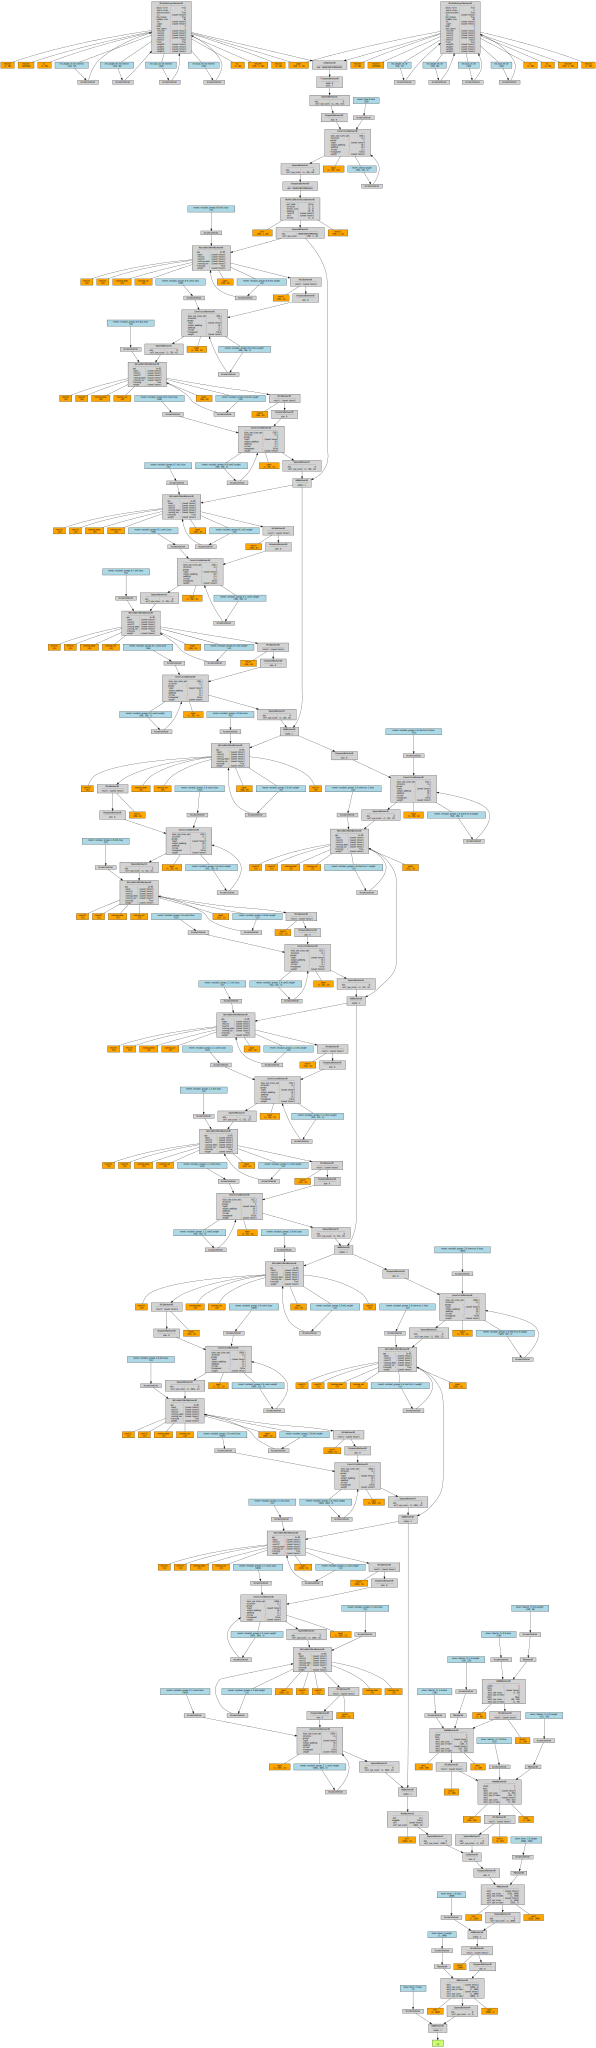

In [56]:
make_dot(out, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)